In [ ]:
!pip install torch torchvision scikit-learn matplotlib seaborn -q

import torch
import torch.nn as nn
import torch.optim as optim
import copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, Subset
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    roc_curve, auc
)
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

In [ ]:
TRAIN_DIR = "/content/drive/MyDrive/datasets/datasets/train"
TEST_DIR  = "/content/drive/MyDrive/datasets/datasets/test"

# > Hyperparameters — matched with centralized study
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_CLASSES = 2
SEED        = 42

# > FL specific
NUM_CLIENTS    = 3
LOCAL_EPOCHS   = 3        # local training epochs per round
FL_ROUNDS      = 10       # federation rounds
VAL_SPLIT      = 0.15     # 85/15

# > Classes — same as centralized
CLASSES = ['NUF', 'UF']

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Configuration set!")
print(f"  Model     : MobileNetV3Small (Best from centralized study)")
print(f"  Input     : Full Image 224x224 (Best preprocessing from study)")
print(f"  Clients   : {NUM_CLIENTS}")
print(f"  FL Rounds : {FL_ROUNDS}")

Device: cuda
Configuration set!
  Model     : MobileNetV3Small (Best from centralized study)
  Input     : Full Image 224x224 (Best preprocessing from study)
  Clients   : 3
  FL Rounds : 10


DATA TRANSFORMS

In [ ]:
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),               #(0.1 rad ≈ 10°)
    transforms.RandomAffine(                     # RandomTranslation equivalent
        degrees=0,
        translate=(0.05, 0.05)
    ),
    transforms.ColorJitter(
        brightness=0.2,                          # RandomBrightness equivalent
        contrast=0.3                             # RandomContrast equivalent
    ),
    transforms.ToTensor(),
    # MobileNetV3 expects [-1, 1] range
    # Equivalent to Rescaling(2/255, -1)
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#Val/Test: no augmentation
transform_val_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms defined!")
print(f"  Train : Augmentation ON  (flip, rotate, translate, color jitter)")

Transforms defined!
  Train : Augmentation ON  (flip, rotate, translate, color jitter)


DATASET LOADING

In [ ]:
full_train_dataset      = datasets.ImageFolder(TRAIN_DIR, transform=transform_train)
full_train_dataset_val  = datasets.ImageFolder(TRAIN_DIR, transform=transform_val_test)
test_dataset            = datasets.ImageFolder(TEST_DIR,  transform=transform_val_test)

print(f"Dataset classes : {full_train_dataset.classes}")
print(f"Train total     : {len(full_train_dataset)}")
print(f"Test total      : {len(test_dataset)}")

Dataset classes : ['NUF', 'UF']
Train total     : 1594
Test total      : 396


Train / Validation Split

In [ ]:
total_train = len(full_train_dataset)
val_size    = int(VAL_SPLIT * total_train)
train_size  = total_train - val_size

# > Stratified split using indices
from sklearn.model_selection import train_test_split

all_indices = list(range(total_train))
all_labels  = [full_train_dataset.targets[i] for i in all_indices]

train_indices, val_indices = train_test_split(
    all_indices,
    test_size    = VAL_SPLIT,
    random_state = SEED,
    stratify     = all_labels
)

# > Train uses augmentation, Val uses no augmentation
train_subset = Subset(full_train_dataset,     train_indices)
val_subset   = Subset(full_train_dataset_val, val_indices)

val_loader = DataLoader(
    val_subset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True
)
test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True
)

print(f"\nSplit (85/15 — same as centralized):")
print(f"  Train      : {len(train_subset)}")
print(f"  Validation : {len(val_subset)}")
print(f"  Test       : {len(test_dataset)}")


Split (85/15 — same as centralized):
  Train      : 1354
  Validation : 240
  Test       : 396


Client Data Distribution - IID & Non-IID

In [ ]:
def create_iid_clients(train_subset, num_clients, seed=42):
    np.random.seed(seed)
    indices    = list(range(len(train_subset)))
    np.random.shuffle(indices)

    client_size    = len(indices) // num_clients
    client_indices = []

    for i in range(num_clients):
        start = i * client_size
        # > Last client gets remaining samples
        end   = start + client_size if i < num_clients - 1 else len(indices)
        client_indices.append(indices[start:end])

    return client_indices


def create_noniid_clients(train_subset, full_dataset, num_clients,
                           alpha=0.5, seed=42):
    """
    Non-IID: Dirichlet distribution
    alpha=0.5 → moderate heterogeneity
    alpha=0.1 → high heterogeneity (extreme class imbalance per client)

    Think of it as: Hospital A has mostly NUF cases,
                    Hospital B has mostly UF cases etc.
    """
    np.random.seed(seed)

    # Get labels for train_subset
    original_indices = train_subset.indices
    labels = np.array([full_dataset.targets[i] for i in original_indices])
    num_classes = len(np.unique(labels))

    # Dirichlet sampling
    class_indices = [np.where(labels == c)[0] for c in range(num_classes)]
    client_indices = [[] for _ in range(num_clients)]

    for c in range(num_classes):
        np.random.shuffle(class_indices[c])
        # Dirichlet proportions for this class across clients
        proportions = np.random.dirichlet(np.repeat(alpha, num_clients))
        proportions = (np.cumsum(proportions) * len(class_indices[c])).astype(int)
        proportions = np.concatenate([[0], proportions])

        for client_id in range(num_clients):
            client_indices[client_id].extend(
                class_indices[c][proportions[client_id]:proportions[client_id+1]].tolist()
            )

    return client_indices


def build_client_loaders(train_subset, client_indices, batch_size):
    loaders = []
    for i, indices in enumerate(client_indices):
        subset = Subset(train_subset, indices)
        loader = DataLoader(
            subset,
            batch_size  = batch_size,
            shuffle     = True,
            num_workers = 2,
            pin_memory  = True
        )
        loaders.append(loader)
        print(f"  Client {i+1}: {len(indices)} samples")
    return loaders


#  Create both IID and Non-IID splits
print(f"\nIID Client Split ({NUM_CLIENTS} clients):")
iid_indices    = create_iid_clients(train_subset, NUM_CLIENTS, SEED)
iid_loaders    = build_client_loaders(train_subset, iid_indices, BATCH_SIZE)

print(f"\nNon-IID Client Split ({NUM_CLIENTS} clients, alpha=0.5):")
noniid_indices = create_noniid_clients(
    train_subset, full_train_dataset, NUM_CLIENTS, alpha=0.5, seed=SEED
)
noniid_loaders = build_client_loaders(train_subset, noniid_indices, BATCH_SIZE)


IID Client Split (3 clients):
  Client 1: 451 samples
  Client 2: 451 samples
  Client 3: 452 samples

Non-IID Client Split (3 clients, alpha=0.5):
  Client 1: 173 samples
  Client 2: 249 samples
  Client 3: 931 samples


Class distribution Visualization

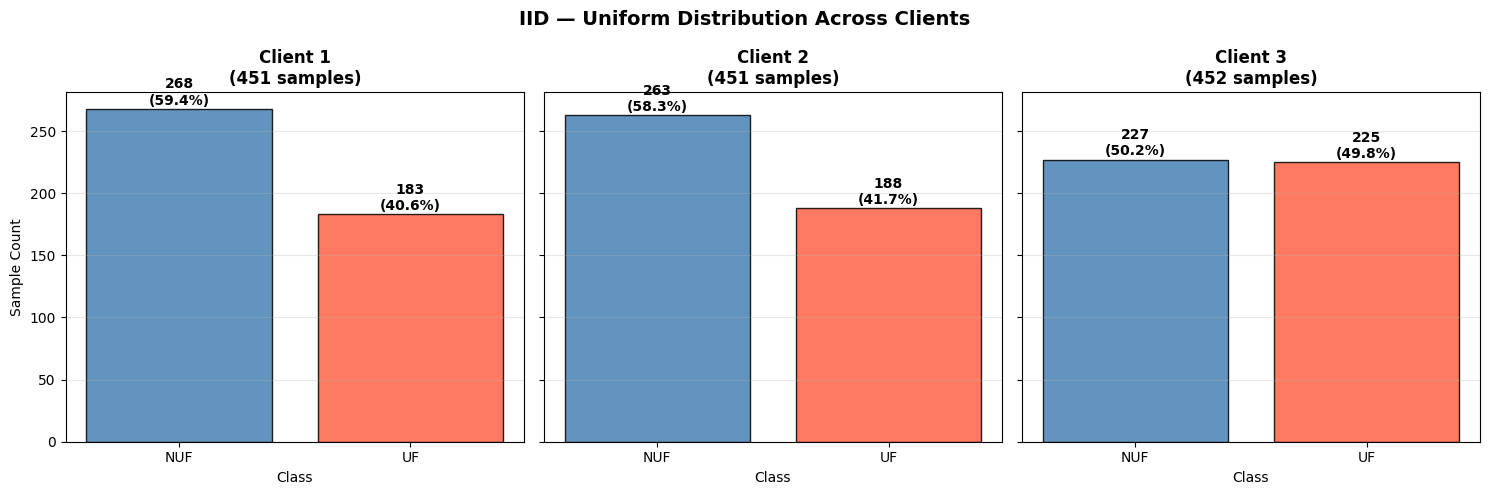

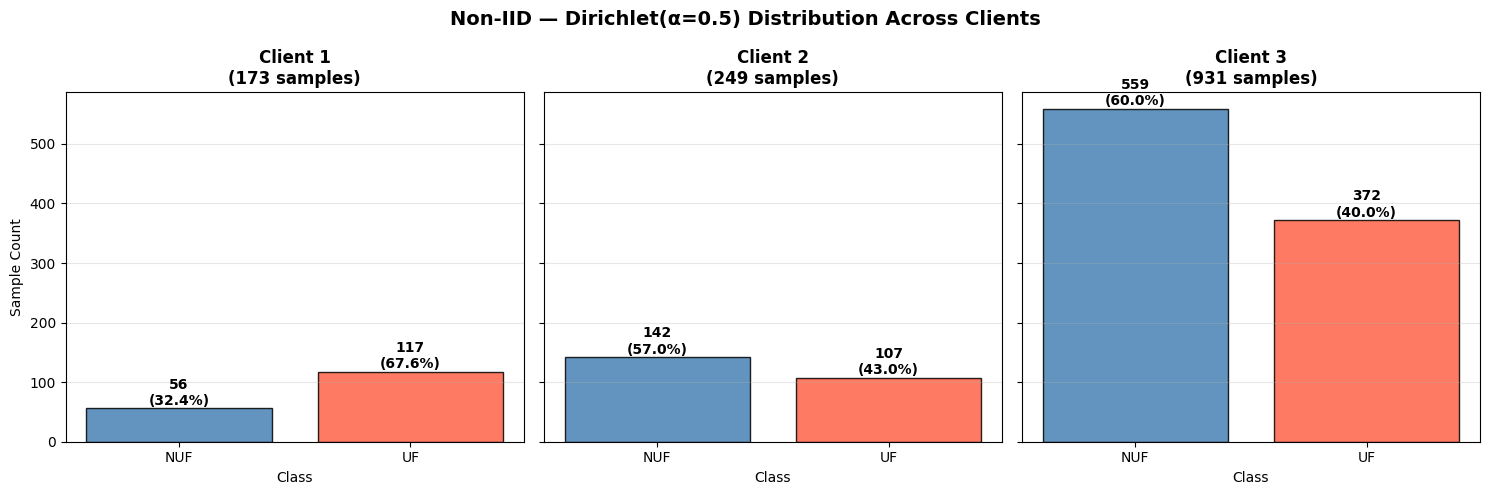

In [ ]:
def plot_client_distribution(client_indices, train_subset,
                              full_dataset, num_clients,
                              title="Client Data Distribution"):

    original_indices = train_subset.indices
    labels = np.array([full_dataset.targets[i] for i in original_indices])

    fig, axes = plt.subplots(1, num_clients,
                              figsize=(5 * num_clients, 5),
                              sharey=True)
    if num_clients == 1:
        axes = [axes]

    colors = ['steelblue', 'tomato']

    for i, (ax, indices) in enumerate(zip(axes, client_indices)):
        client_labels = labels[indices]
        counts = [np.sum(client_labels == c) for c in range(2)]
        total  = sum(counts)

        bars = ax.bar(CLASSES, counts, color=colors, alpha=0.85, edgecolor='black')
        ax.set_title(f"Client {i+1}\n({total} samples)",
                     fontsize=12, fontweight='bold')
        ax.set_xlabel("Class")
        if i == 0:
            ax.set_ylabel("Sample Count")
        ax.grid(axis='y', alpha=0.3)

        for bar, count in zip(bars, counts):
            ax.text(
                bar.get_x() + bar.get_width() / 2.,
                bar.get_height() + 1,
                f'{count}\n({count/total*100:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold'
            )

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_client_distribution(
    iid_indices, train_subset, full_train_dataset,
    NUM_CLIENTS, "IID — Uniform Distribution Across Clients"
)
plot_client_distribution(
    noniid_indices, train_subset, full_train_dataset,
    NUM_CLIENTS, "Non-IID — Dirichlet(α=0.5) Distribution Across Clients"
)

Model (MobileNetV3small)

In [ ]:
def get_mobilenetv3small(num_classes=2, freeze_base=True):

    model = models.mobilenet_v3_small(pretrained=True)

    # Freeze base (Phase 1 — feature extraction)
    if freeze_base:
        for param in model.features.parameters():
            param.requires_grad = False

    in_features = model.classifier[0].in_features

    model.classifier = nn.Sequential(
        nn.Linear(in_features, 128),    # Dense(128)
        nn.Hardswish(),                  # MobileNetV3 activation
        nn.BatchNorm1d(128),             # BatchNormalization
        nn.Dropout(p=0.3),               # Dropout(0.3)
        nn.Linear(128, 64),
        nn.Hardswish(),
        nn.Dropout(p=0.2),               # Dropout(0.2)
        nn.Linear(64, num_classes)       # Output layer
    )

    return model.to(device)


# > Test model
test_model = get_mobilenetv3small(num_classes=NUM_CLASSES)
total_params     = sum(p.numel() for p in test_model.parameters())
trainable_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)

print(f"Model: MobileNetV3Small")
print(f"  Total params     : {total_params/1e6:.2f}M")
print(f"  Trainable params : {trainable_params/1e6:.2f}M")
print(f"  Frozen params    : {(total_params-trainable_params)/1e6:.2f}M")
del test_model

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 214MB/s]


Model: MobileNetV3Small
  Total params     : 1.01M
  Trainable params : 0.08M
  Frozen params    : 0.93M


LOSS & OPTIMIZER

In [ ]:
criterion = nn.CrossEntropyLoss()

def get_optimizer(model, lr=1e-3):
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr           = lr,
        weight_decay = 1e-4
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode     = 'min',
        factor   = 0.3,
        patience = 3
    )
    return optimizer, scheduler


print("Loss & Optimizer configured!")
print("  Loss      : CrossEntropyLoss (multi-class, matches centralized)")
print("  Optimizer : Adam (lr=1e-3, same as centralized)")
print("  Scheduler : ReduceLROnPlateau (factor=0.3, patience=3)")

Loss & Optimizer configured!
  Loss      : CrossEntropyLoss (multi-class, matches centralized)
  Optimizer : Adam (lr=1e-3, same as centralized)
  Scheduler : ReduceLROnPlateau (factor=0.3, patience=3)


Local Training

In [ ]:
def train_local(model, client_loader, val_loader,
                local_epochs=LOCAL_EPOCHS, lr=1e-3,
                verbose=False):

    optimizer, scheduler = get_optimizer(model, lr=lr)

    local_train_losses = []
    local_val_losses   = []

    for epoch in range(local_epochs):
        # Training phase
        model.train()
        running_loss = 0.0

        for images, labels in client_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()

            #  Gradient clipping for FL stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_train_loss = running_loss / len(client_loader.dataset)
        local_train_losses.append(epoch_train_loss)

        #  Validation phase
        model.eval()
        val_running_loss = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss    = criterion(outputs, labels)
                val_running_loss += loss.item() * images.size(0)

        epoch_val_loss = val_running_loss / len(val_loader.dataset)
        local_val_losses.append(epoch_val_loss)

        scheduler.step(epoch_val_loss)

        if verbose:
            print(f"    Epoch {epoch+1}/{local_epochs} | "
                  f"Train Loss: {epoch_train_loss:.4f} | "
                  f"Val Loss: {epoch_val_loss:.4f}")

    return model.state_dict(), local_train_losses, local_val_losses

FEDAVG - WEIGHTED AGGREGATION

In [ ]:
def fedavg_weighted(global_model, client_weights_list, client_sizes):
    """
    Weighted FedAvg:
    w_global = Σ (n_k / N) * w_k
    where n_k = client k dataset size, N = total samples.
    """
    total_samples = sum(client_sizes)
    new_state     = copy.deepcopy(global_model.state_dict())

    for key in new_state.keys():
        # Weighted sum
        weighted_sum = torch.zeros_like(
            new_state[key], dtype=torch.float32
        )
        for client_state, size in zip(client_weights_list, client_sizes):
            weight       = size / total_samples
            weighted_sum += client_state[key].float() * weight

        new_state[key] = weighted_sum

    global_model.load_state_dict(new_state)
    return global_model


print("Weighted FedAvg aggregation defined!")
print("  Formula: w_global = Σ (n_k/N) × w_k")
print("  Handles unequal client sizes correctly")

Weighted FedAvg aggregation defined!
  Formula: w_global = Σ (n_k/N) × w_k
  Handles unequal client sizes correctly


Evaluation

In [ ]:
def evaluate_model(model, loader, return_probs=False):
    model.eval()

    y_true  = []
    y_pred  = []
    y_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = torch.softmax(model(images), dim=1)
            preds   = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(outputs[:, 1].cpu().numpy())   # UF class prob

    y_true  = np.array(y_true)
    y_pred  = np.array(y_pred)
    y_probs = np.array(y_probs)

    # > Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn + 1e-8)
        specificity = tn / (tn + fp + 1e-8)
        precision   = tp / (tp + fp + 1e-8)
    else:
        sensitivity = specificity = precision = 0.0

    accuracy = accuracy_score(y_true, y_pred)
    f1       = f1_score(y_true, y_pred, zero_division=0)
    auc_score = roc_auc_score(y_true, y_probs)

    metrics = {
        'accuracy'   : accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'precision'  : precision,
        'f1'         : f1,
        'auc'        : auc_score,
        'y_true'     : y_true,
        'y_pred'     : y_pred,
        'y_probs'    : y_probs,
        'cm'         : cm
    }

    if return_probs:
        return metrics, y_probs
    return metrics

print("  Metrics: Accuracy, Sensitivity, Specificity, Precision, F1, AUC")

  Metrics: Accuracy, Sensitivity, Specificity, Precision, F1, AUC


Federated Training

In [ ]:
def run_federated_training(
        num_clients,
        client_loaders,
        val_loader,
        fl_rounds     = FL_ROUNDS,
        local_epochs  = LOCAL_EPOCHS,
        mode          = "IID",
        verbose_local = False
):

    print(f"  FEDERATED TRAINING — {mode} | {num_clients} Clients")
    print(f"  Rounds: {fl_rounds} | Local Epochs/Round: {local_epochs}")
    print(f"{'='*65}")

    #  Initialize global model
    global_model = get_mobilenetv3small(
        num_classes = NUM_CLASSES,
        freeze_base = True
    )

    #  Track history
    history = {
        'round'      : [],
        'val_loss'   : [],
        'val_acc'    : [],
        'val_auc'    : [],
        'val_f1'     : [],
        'client_losses': []
    }

    #  Client sizes for weighted FedAvg
    client_sizes = [len(loader.dataset) for loader in client_loaders]

    best_val_auc   = 0.0
    best_model_wts = copy.deepcopy(global_model.state_dict())

    for round_num in range(1, fl_rounds + 1):
        print(f"\n--- Round {round_num}/{fl_rounds} ---")

        client_weights_list  = []
        round_client_losses  = []

        #  Each client trains locally
        for client_id in range(num_clients):
            print(f"  Client {client_id+1} training...", end='')

            #  Copy global weights to local model
            local_model = get_mobilenetv3small(
                num_classes = NUM_CLASSES,
                freeze_base = True
            )
            local_model.load_state_dict(
                copy.deepcopy(global_model.state_dict())
            )

            #  Local training
            updated_weights, train_losses, val_losses = train_local(
                local_model,
                client_loaders[client_id],
                val_loader,
                local_epochs = local_epochs,
                verbose      = verbose_local
            )

            client_weights_list.append(updated_weights)
            round_client_losses.append(np.mean(val_losses))
            print(f" done | Val Loss: {np.mean(val_losses):.4f}")

        #  FedAvg aggregation
        global_model = fedavg_weighted(
            global_model, client_weights_list, client_sizes
        )

        #  Evaluate global model on validation set
        metrics = evaluate_model(global_model, val_loader)

        history['round'].append(round_num)
        history['val_acc'].append(metrics['accuracy'])
        history['val_auc'].append(metrics['auc'])
        history['val_f1'].append(metrics['f1'])
        history['client_losses'].append(round_client_losses)

        #  Approximate val loss as mean of client val losses
        history['val_loss'].append(np.mean(round_client_losses))

        #  Save best model
        if metrics['auc'] > best_val_auc:
            best_val_auc   = metrics['auc']
            best_model_wts = copy.deepcopy(global_model.state_dict())

        print(f"  [Global] "
              f"Acc: {metrics['accuracy']:.4f} | "
              f"AUC: {metrics['auc']:.4f} | "
              f"F1: {metrics['f1']:.4f} | "
              f"Sens: {metrics['sensitivity']:.4f} | "
              f"Spec: {metrics['specificity']:.4f}")

    #  Restore best weights
    global_model.load_state_dict(best_model_wts)
    print(f"\nBest Val AUC: {best_val_auc:.4f}")

    return global_model, history


print("Federated training loop defined!")

Federated training loop defined!


Centralized Baseline Training

In [ ]:
def run_centralized_training(
        train_subset,
        val_loader,
        epochs  = FL_ROUNDS * LOCAL_EPOCHS,
        verbose = True
):

    print(f"  CENTRALIZED TRAINING — MobileNetV3Small")
    print(f"  Total Epochs: {epochs} (= {FL_ROUNDS} rounds × {LOCAL_EPOCHS} local epochs)")
    print(f"{'='*65}")

    full_train_loader = DataLoader(
        train_subset,
        batch_size  = BATCH_SIZE,
        shuffle     = True,
        num_workers = 2,
        pin_memory  = True
    )

    model     = get_mobilenetv3small(NUM_CLASSES, freeze_base=True)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr           = 1e-3,
        weight_decay = 1e-4
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode    = 'min',
        factor  = 0.3,
        patience= 3
    )

    history = {
        'epoch'     : [],
        'val_acc'   : [],
        'val_auc'   : [],
        'val_f1'    : [],
        'val_loss'  : [],
        'train_loss': []
    }

    best_val_auc   = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(1, epochs + 1):
        #  Training
        model.train()
        train_loss = 0.0

        for images, labels in full_train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * images.size(0)

        epoch_train_loss = train_loss / len(full_train_loader.dataset)

        #  Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss    = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)

        epoch_val_loss = val_loss / len(val_loader.dataset)
        scheduler.step(epoch_val_loss)

        #  Metrics
        metrics = evaluate_model(model, val_loader)

        history['epoch'].append(epoch)
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(metrics['accuracy'])
        history['val_auc'].append(metrics['auc'])
        history['val_f1'].append(metrics['f1'])

        if metrics['auc'] > best_val_auc:
            best_val_auc   = metrics['auc']
            best_model_wts = copy.deepcopy(model.state_dict())

        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f"  Epoch {epoch:3d}/{epochs} | "
                  f"Train Loss: {epoch_train_loss:.4f} | "
                  f"Val Loss: {epoch_val_loss:.4f} | "
                  f"Val AUC: {metrics['auc']:.4f}")

    model.load_state_dict(best_model_wts)
    print(f"\nBest Val AUC: {best_val_auc:.4f}")
    return model, history


print("Centralized training function defined!")

Centralized training function defined!


Run Experiment

In [ ]:
# 1. Centralized Baseline
central_model, central_history = run_centralized_training(
    train_subset, val_loader,
    epochs  = FL_ROUNDS * LOCAL_EPOCHS,
    verbose = True
)

# 2. Federated IID
fed_iid_model, fed_iid_history = run_federated_training(
    num_clients    = NUM_CLIENTS,
    client_loaders = iid_loaders,
    val_loader     = val_loader,
    fl_rounds      = FL_ROUNDS,
    local_epochs   = LOCAL_EPOCHS,
    mode           = "IID"
)

# 3. Federated Non-IID
fed_noniid_model, fed_noniid_history = run_federated_training(
    num_clients    = NUM_CLIENTS,
    client_loaders = noniid_loaders,
    val_loader     = val_loader,
    fl_rounds      = FL_ROUNDS,
    local_epochs   = LOCAL_EPOCHS,
    mode           = "Non-IID"
)

print("\nAll experiments completed!")

  CENTRALIZED TRAINING — MobileNetV3Small
  Total Epochs: 30 (= 10 rounds × 3 local epochs)
  Epoch   1/30 | Train Loss: 0.4164 | Val Loss: 0.5671 | Val AUC: 0.8946
  Epoch   5/30 | Train Loss: 0.2543 | Val Loss: 0.3573 | Val AUC: 0.9299
  Epoch  10/30 | Train Loss: 0.2196 | Val Loss: 0.3381 | Val AUC: 0.9444
  Epoch  15/30 | Train Loss: 0.1878 | Val Loss: 0.3459 | Val AUC: 0.9471
  Epoch  20/30 | Train Loss: 0.1903 | Val Loss: 0.3316 | Val AUC: 0.9491
  Epoch  25/30 | Train Loss: 0.2040 | Val Loss: 0.3366 | Val AUC: 0.9490
  Epoch  30/30 | Train Loss: 0.1720 | Val Loss: 0.3378 | Val AUC: 0.9492

Best Val AUC: 0.9492

  FEDERATED TRAINING — IID | 3 Clients
  Rounds: 10 | Local Epochs/Round: 3

--- Round 1/10 ---
  Client 1 training... done | Val Loss: 0.5218
  Client 2 training... done | Val Loss: 0.7686
  Client 3 training... done | Val Loss: 0.5991
  [Global] Acc: 0.7083 | AUC: 0.9046 | F1: 0.7464 | Sens: 0.9717 | Spec: 0.5000

--- Round 2/10 ---
  Client 1 training... done | Val Los

Convergence Visualization

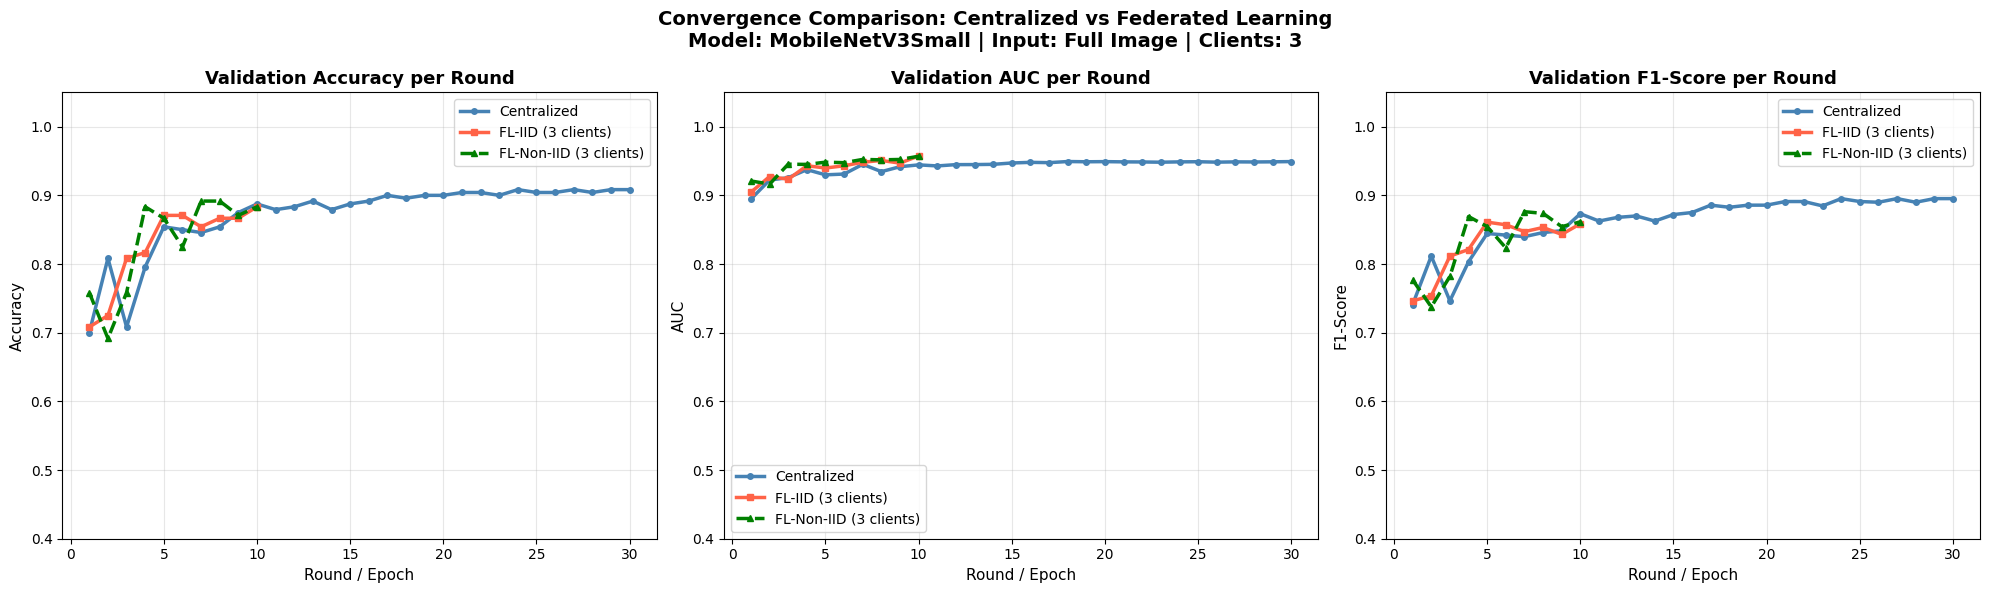

In [ ]:
def plot_convergence(central_history, iid_history, noniid_history):

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    metrics_to_plot = [
        ('val_acc', 'Accuracy',      'Validation Accuracy per Round'),
        ('val_auc', 'AUC',           'Validation AUC per Round'),
        ('val_f1',  'F1-Score',      'Validation F1-Score per Round'),
    ]

    colors = {
        'Centralized' : 'steelblue',
        'FL-IID'      : 'tomato',
        'FL-Non-IID'  : 'green'
    }

    for ax, (metric, ylabel, title) in zip(axes, metrics_to_plot):

        #  Centralized
        ax.plot(
            central_history['epoch'],
            central_history[metric],
            color     = colors['Centralized'],
            linewidth = 2.5,
            marker    = 'o',
            markersize= 4,
            label     = 'Centralized'
        )

        #  FL IID
        ax.plot(
            iid_history['round'],
            iid_history[metric],
            color     = colors['FL-IID'],
            linewidth = 2.5,
            marker    = 's',
            markersize= 5,
            label     = f'FL-IID ({NUM_CLIENTS} clients)'
        )

        #  FL Non-IID
        ax.plot(
            noniid_history['round'],
            noniid_history[metric],
            color     = colors['FL-Non-IID'],
            linewidth = 2.5,
            marker    = '^',
            markersize= 5,
            linestyle = '--',
            label     = f'FL-Non-IID ({NUM_CLIENTS} clients)'
        )

        ax.set_title(title,      fontsize=13, fontweight='bold')
        ax.set_xlabel("Round / Epoch", fontsize=11)
        ax.set_ylabel(ylabel,    fontsize=11)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0.4, 1.05)

    plt.suptitle(
        "Convergence Comparison: Centralized vs Federated Learning\n"
        f"Model: MobileNetV3Small | Input: Full Image | Clients: {NUM_CLIENTS}",
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


plot_convergence(central_history, fed_iid_history, fed_noniid_history)

Final Test Evaluation- all model

In [ ]:
print("\n" + "="*70)
print("FINAL TEST SET EVALUATION")
print("="*70)

all_results = {}

#  Evaluate all models
for model_obj, name in [
    (central_model,     "Centralized"),
    (fed_iid_model,     f"FL-IID ({NUM_CLIENTS} clients)"),
    (fed_noniid_model,  f"FL-Non-IID ({NUM_CLIENTS} clients)")
]:
    print(f"\n--- {name} ---")
    metrics = evaluate_model(model_obj, test_loader)
    all_results[name] = metrics

    print(f"  Accuracy    : {metrics['accuracy']:.4f}")
    print(f"  Sensitivity : {metrics['sensitivity']:.4f}")
    print(f"  Specificity : {metrics['specificity']:.4f}")
    print(f"  Precision   : {metrics['precision']:.4f}")
    print(f"  F1-Score    : {metrics['f1']:.4f}")
    print(f"  AUC         : {metrics['auc']:.4f}")
    print()
    print(classification_report(
        metrics['y_true'], metrics['y_pred'],
        target_names=CLASSES
    ))


FINAL TEST SET EVALUATION

--- Centralized ---
  Accuracy    : 0.9091
  Sensitivity : 0.9364
  Specificity : 0.8879
  Precision   : 0.8663
  F1-Score    : 0.9000
  AUC         : 0.9718

              precision    recall  f1-score   support

         NUF       0.95      0.89      0.92       223
          UF       0.87      0.94      0.90       173

    accuracy                           0.91       396
   macro avg       0.91      0.91      0.91       396
weighted avg       0.91      0.91      0.91       396


--- FL-IID (3 clients) ---
  Accuracy    : 0.9268
  Sensitivity : 0.9133
  Specificity : 0.9372
  Precision   : 0.9186
  F1-Score    : 0.9159
  AUC         : 0.9727

              precision    recall  f1-score   support

         NUF       0.93      0.94      0.94       223
          UF       0.92      0.91      0.92       173

    accuracy                           0.93       396
   macro avg       0.93      0.93      0.93       396
weighted avg       0.93      0.93      0.93    

Confusion Matrice

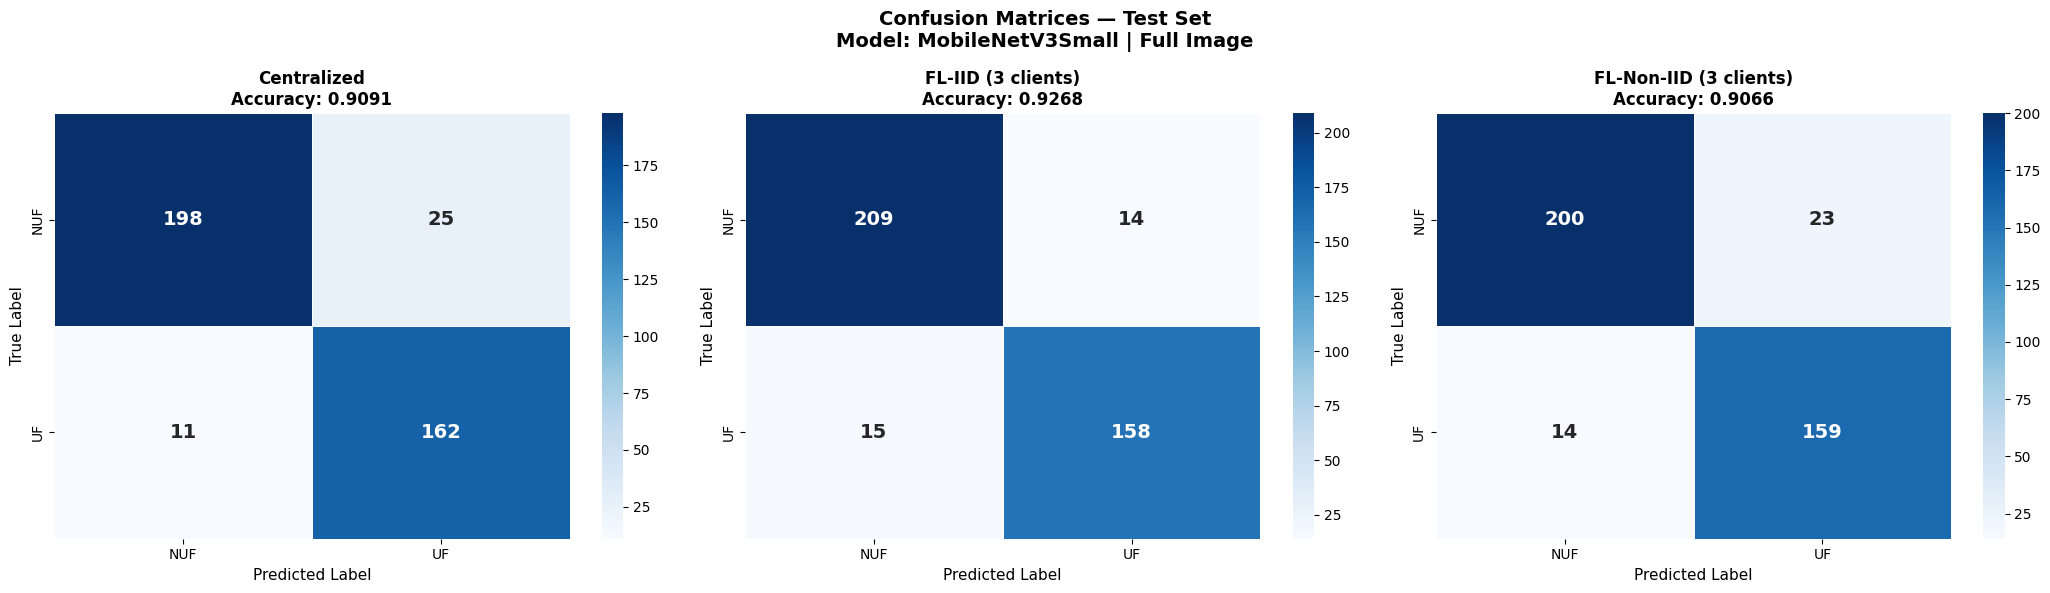

In [ ]:
def plot_all_confusion_matrices(all_results, classes):
    n      = len(all_results)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 6))

    if n == 1:
        axes = [axes]

    for ax, (name, metrics) in zip(axes, all_results.items()):
        cm = metrics['cm']
        sns.heatmap(
            cm,
            annot       = True,
            fmt         = 'd',
            cmap        = 'Blues',
            xticklabels = classes,
            yticklabels = classes,
            ax          = ax,
            linewidths  = 0.5,
            annot_kws   = {'size': 14, 'weight': 'bold'}
        )
        acc = metrics['accuracy']
        ax.set_title(f"{name}\nAccuracy: {acc:.4f}",
                     fontsize=12, fontweight='bold')
        ax.set_xlabel("Predicted Label", fontsize=11)
        ax.set_ylabel("True Label",      fontsize=11)

    plt.suptitle(
        "Confusion Matrices — Test Set\n"
        f"Model: MobileNetV3Small | Full Image",
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


plot_all_confusion_matrices(all_results, CLASSES)

Roc Curves

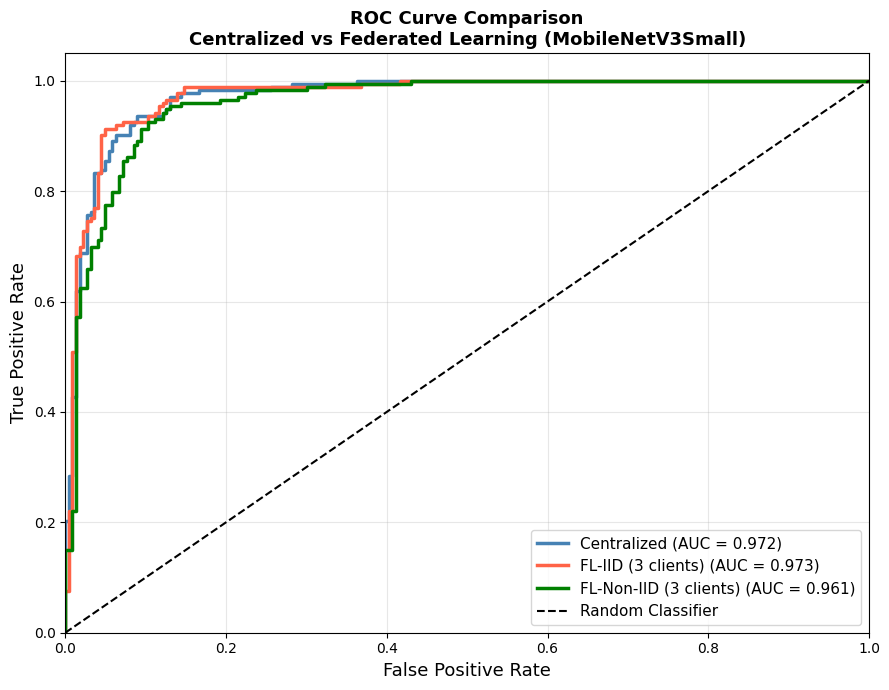

In [ ]:
def plot_roc_comparison(all_results):
    colors = ['steelblue', 'tomato', 'green', 'purple']

    plt.figure(figsize=(9, 7))

    for (name, metrics), color in zip(all_results.items(), colors):
        fpr, tpr, _ = roc_curve(metrics['y_true'], metrics['y_probs'])
        auc_val     = auc(fpr, tpr)
        plt.plot(
            fpr, tpr,
            color     = color,
            lw        = 2.5,
            label     = f"{name} (AUC = {auc_val:.3f})"
        )

    plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate", fontsize=13)
    plt.ylabel("True Positive Rate",  fontsize=13)
    plt.title(
        "ROC Curve Comparison\n"
        "Centralized vs Federated Learning (MobileNetV3Small)",
        fontsize=13, fontweight='bold'
    )
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_roc_comparison(all_results)

Final Summary Table

In [ ]:
import pandas as pd

def create_fl_summary_table(all_results):
    rows = []
    for name, metrics in all_results.items():
        rows.append({
            'Model/Setting' : name,
            'Accuracy'      : f"{metrics['accuracy']:.4f}",
            'Sensitivity'   : f"{metrics['sensitivity']:.4f}",
            'Specificity'   : f"{metrics['specificity']:.4f}",
            'Precision'     : f"{metrics['precision']:.4f}",
            'F1-Score'      : f"{metrics['f1']:.4f}",
            'AUC'           : f"{metrics['auc']:.4f}",
        })

    df = pd.DataFrame(rows)

    print("\n" + "="*80)
    print("FINAL SUMMARY TABLE — FEDERATED vs CENTRALIZED")
    print("Model: MobileNetV3Small | Input: Full Image (Best from Study)")
    print("="*80)
    print(df.to_string(index=False))
    print("="*80)

    # > Gap analysis
    print("\nFederation Gap Analysis (vs Centralized):")
    cent_acc = float(rows[0]['Accuracy'])
    cent_auc = float(rows[0]['AUC'])

    for row in rows[1:]:
        acc_gap = float(row['Accuracy']) - cent_acc
        auc_gap = float(row['AUC'])      - cent_auc
        sign_acc = '+' if acc_gap >= 0 else ''
        sign_auc = '+' if auc_gap >= 0 else ''
        print(f"  {row['Model/Setting']:30s} | "
              f"Acc Gap: {sign_acc}{acc_gap:.4f} | "
              f"AUC Gap: {sign_auc}{auc_gap:.4f}")

    return df


summary_df = create_fl_summary_table(all_results)


FINAL SUMMARY TABLE — FEDERATED vs CENTRALIZED
Model: MobileNetV3Small | Input: Full Image (Best from Study)
         Model/Setting Accuracy Sensitivity Specificity Precision F1-Score    AUC
           Centralized   0.9091      0.9364      0.8879    0.8663   0.9000 0.9718
    FL-IID (3 clients)   0.9268      0.9133      0.9372    0.9186   0.9159 0.9727
FL-Non-IID (3 clients)   0.9066      0.9191      0.8969    0.8736   0.8958 0.9609

Federation Gap Analysis (vs Centralized):
  FL-IID (3 clients)             | Acc Gap: +0.0177 | AUC Gap: +0.0009
  FL-Non-IID (3 clients)         | Acc Gap: -0.0025 | AUC Gap: -0.0109
